# Praktikum Pertemuan 4 Data Science

Nama : Rangga Saputra

NIM : 250401020034

Dosen Pengajar : Syahid Abdullah, S.Si., M.Kom.

In [22]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

df = sns.load_dataset('iris')
print('Shape:', df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(3))

Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100

Inisialisasi pustaka:
- `pandas` untuk manipulasi data
- `numpy` untuk operasi numerik
- `matplotlib.pyplot` dan `seaborn` untuk visualisasi data
- `scipy.stats` untuk fungsi statistik.

Kemudian memuat dataset Iris menggunakan `sns.load_dataset('iris')` dan menampilkan bentuknya (`shape`), tipe data (`dtypes`), beberapa baris pertama (`head()`), serta statistik deskriptif (`describe()`).

In [23]:
for col_name in df.select_dtypes(include='number').columns:
  col = df[col_name]
  print(f'\n=== {col_name} ===')
  print(f' Mean : {col.mean():.3f}')
  print(f' Median : {col.median():.3f}')
  print(f' Std Dev : {col.std():.3f}')
  print(f' Skewness : {col.skew():.3f}')
  print(f' Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
 Mean : 5.843
 Median : 5.800
 Std Dev : 0.828
 Skewness : 0.315
 Kurtosis : -0.552

=== sepal_width ===
 Mean : 3.057
 Median : 3.000
 Std Dev : 0.436
 Skewness : 0.319
 Kurtosis : 0.228

=== petal_length ===
 Mean : 3.758
 Median : 4.350
 Std Dev : 1.765
 Skewness : -0.275
 Kurtosis : -1.402

=== petal_width ===
 Mean : 1.199
 Median : 1.300
 Std Dev : 0.762
 Skewness : -0.103
 Kurtosis : -1.341


Menghitung dan mencetak statistik deskriptif rinci untuk setiap kolom numerik dalam DataFrame (`df`). Untuk setiap kolom, akan ditampilkan mean, median, standar deviasi, skewness, dan kurtosis. Statistik ini membantu dalam memahami tendensi sentral, penyebaran, dan bentuk distribusi untuk setiap fitur.

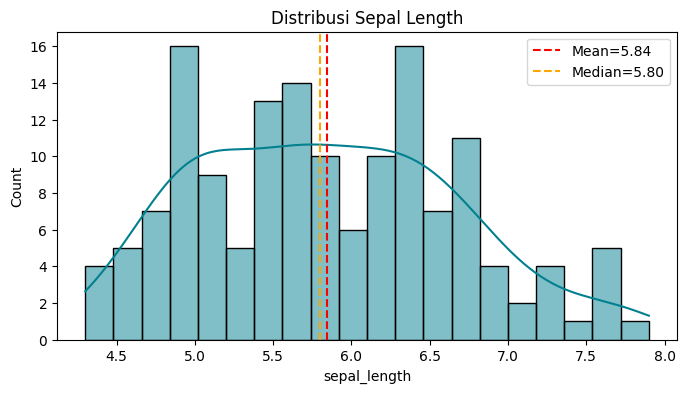

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True,
    color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red',
    linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange',
    linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length'); ax.legend(); plt.show()

Menghasilkan histogram dengan Estimasi Kepadatan Kernel (KDE) untuk kolom `sepal_length`. Ini juga menambahkan garis vertikal yang menunjukkan mean (garis putus-putus merah) dan median (garis putus-putus oranye) dari `sepal_length`. Visualisasi ini membantu untuk memahami distribusi `sepal_length` dan mengidentifikasi apakah simetris, miring, atau multimodal.

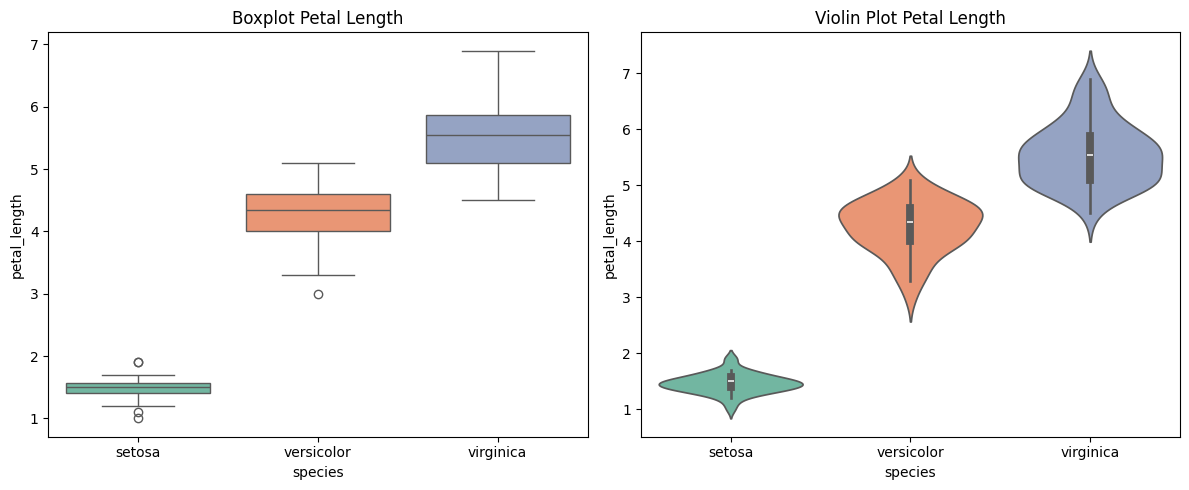

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='species', y='petal_length',
    palette='Set2', hue='species', legend=False, ax=axes[0])
axes[0].set_title('Boxplot Petal Length')
sns.violinplot(data=df, x='species', y='petal_length',
    palette='Set2', inner='box', hue='species', legend=False, ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')
plt.tight_layout(); plt.show()

Block code ini membuat dua subplot, yaitu boxplot dan violin plot, keduanya menunjukkan distribusi `petal_length` di antara `species` yang berbeda.

Boxplot mengilustrasikan ringkasan lima angka (minimum, kuartil pertama, median, kuartil ketiga, maksimum) dan outlier.

Violin plot menggabungkan boxplot dengan estimasi kepadatan kernel, menunjukkan bentuk distribusi dengan lebih jelas.

Kedua plot menggunakan `species` untuk pengelompokan dan warna yang berbeda untuk setiap spesies agar lebih mudah dibedakan secara visual, sekaligus mengatasi `FutureWarning` dengan secara eksplisit mengatur `hue='species'` dan `legend=False`.

In [26]:
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))
import numpy as np
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


Menghitung matriks korelasi Pearson untuk semua kolom numerik dalam dataset, tidak termasuk kolom 'species'. Kemudian mencetak matriks korelasi yang sudah dibulatkan.

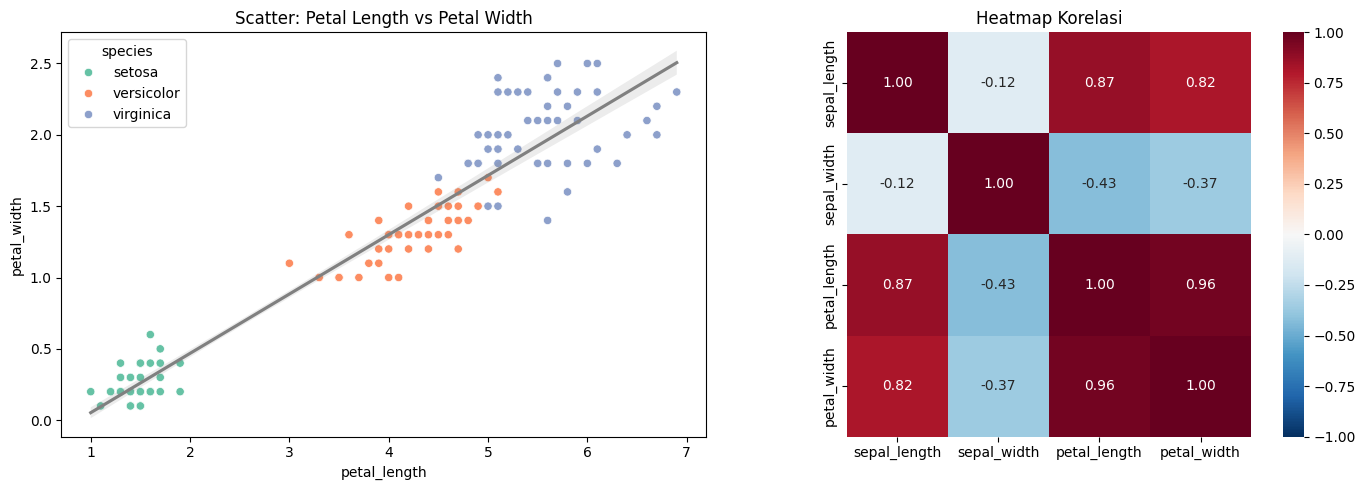

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width',
 hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width',
 scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
 vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')
plt.tight_layout(); plt.show()

Menghasilkan dua visualisasi: scatter plot dan heatmap.

Scatter plot menampilkan hubungan antara `petal_length` dan `petal_width`, diwarnai berdasarkan `species`, dengan garis regresi untuk menunjukkan tren.

Heatmap memvisualisasikan seluruh matriks korelasi Pearson, dengan anotasi yang menunjukkan koefisien korelasi.